# Neural Network Training


## Softmax Function

In [1]:
import numpy as np

In [4]:
# softmax version 1
def softmax(x):
    """Compute the softmax of vector x."""
    e_x = np.exp(x)
    #return e_x / e_x.sum()
    s_x = np.sum(e_x)
    return e_x / s_x

In [5]:
# test the softmax function
x = np.array([1.0, 2.0, 3.0])
print(softmax(x))

[0.09003057 0.24472847 0.66524096]


In [7]:
# test the softmax function with a big number
x = np.array([1.0, 2.0, 900])
print(softmax(x))

[ 0.  0. nan]


/tmp/ipykernel_18754/2713309464.py:4: RuntimeWarning: overflow encountered in exp
  e_x = np.exp(x)
/tmp/ipykernel_18754/2713309464.py:7: RuntimeWarning: invalid value encountered in divide
  return e_x / s_x


In [8]:
# softmax version 2 (numerically stable)
def softmax_stable(x):
    """Compute the softmax of vector x in a numerically stable way."""
    c = np.max(x)
    e_x = np.exp(x - c)
    s_x = np.sum(e_x)
    return e_x / s_x

In [11]:
# test this new softmax function with origial same values   
x = np.array([1.0, 2.0, 3.0])
print(softmax_stable(x))

[0.09003057 0.24472847 0.66524096]


In [10]:
# test the softmax function with a larger value 
x = np.array([1.0, 2.0, 900])
print(softmax_stable(x))

[0. 0. 1.]


# This is preparation for MnistData class

## Download Mnist Dataset

In [23]:
# import packages here
import os
import gzip
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import random
import pickle

In [24]:
mnist_files = {
    'x_train': 'train-images-idx3-ubyte.gz',
    'y_train': 'train-labels-idx1-ubyte.gz',
    'x_test': 't10k-images-idx3-ubyte.gz',
    'y_test': 't10k-labels-idx1-ubyte.gz'
}


In [25]:
dataset_path = 'data/mnist/'
mnist_data_pickle = os.path.join(dataset_path, 'mnist_data.pkl')

In [26]:
def download_mnist_data():
    base_url = 'http://jrkwon.com/data/ece5831/mnist/'

    # To avoid 406 Not Acceptable error, we need to set the User-Agent header
    opener = urllib.request.build_opener()
    opener.addheaders = [('Accept', '')]
    urllib.request.install_opener(opener)

    for key, filename in mnist_files.items():
        if os.path.exists(dataset_path) == False:
            os.makedirs(dataset_path)
        file_path = os.path.join(dataset_path, filename)

        url = base_url + filename
        # if the file already exists, skip downloading
        if os.path.exists(file_path):
            print(f'{filename} already exists, skipping download.')
            continue
        print(f'Downloading {filename}...')
        urllib.request.urlretrieve(url, file_path)
        print(f'{filename} downloaded at {file_path}.')

In [27]:
# test the download function
download_mnist_data()

train-images-idx3-ubyte.gz already exists, skipping download.
train-labels-idx1-ubyte.gz already exists, skipping download.
t10k-images-idx3-ubyte.gz already exists, skipping download.
t10k-labels-idx1-ubyte.gz already exists, skipping download.


## Prepare Mnist Data to Return

In [28]:
mnist_data = {
    "x_train": None,
    "y_train": None,
    "x_test": None,
    "y_test": None
}

In [29]:
def load_mnist_images(filename): 
    with gzip.open(filename, 'rb') as f:
        # The first 16 bytes are header information, so we skip them
        data = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28*28)
    return data

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        # The first 8 bytes are header information, so we skip them
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

def load_mnist_data():
    # if the pickle file already exists, load the data from the pickle file
    if os.path.exists(mnist_data_pickle):
        print(f'Loading MNIST data from {mnist_data_pickle}...')
        with open(mnist_data_pickle, 'rb') as f:
            mnist_data_from_pickle = pickle.load(f)
        print('MNIST data loaded from pickle file.')
        (x_train, y_train), (x_test, y_test) = (mnist_data_from_pickle['x_train'], mnist_data_from_pickle['y_train']), (mnist_data_from_pickle['x_test'], mnist_data_from_pickle['y_test'])

    else:
        for key, filename in mnist_files.items():
            file_path = os.path.join(dataset_path, filename)
            if 'x_' in key:
                mnist_data[key] = load_mnist_images(file_path)
            elif 'y_' in key:
                mnist_data[key] = load_mnist_labels(file_path)
            else:
                raise ValueError(f'Unknown file type: {file_path}')

        # save the mnist_data dictionary to a pickle file for later use    
        with open(mnist_data_pickle, 'wb') as f:
            pickle.dump(mnist_data, f)
    
        (x_train, y_train), (x_test, y_test) = (mnist_data['x_train'], mnist_data['y_train']), (mnist_data['x_test'], mnist_data['y_test'])
    
    return (x_train, y_train), (x_test, y_test)


In [30]:
# test the load function
(x_train, y_train), (x_test, y_test) = load_mnist_data()

# keep this if the mnist_data dictionary has the loaded data
print("mnist_data dictionary:")
print(mnist_data['x_train'].shape)  # should be (60000, 784)
print(mnist_data['y_train'].shape)  # should be (60000,)
print(mnist_data['x_test'].shape)   # should be (10000, 784)
print(mnist_data['y_test'].shape)   # should be (10000,)

# print x_train and y_train to check if they are loaded correctly
print("return values of load_mnist_data function:")
print(x_train.shape)  # should be (60000, 784)
print(y_train.shape)  # should be (60000,)
print(x_test.shape)   # should be (10000, 784)
print(y_test.shape)   # should be (10000,)

Loading MNIST data from data/mnist/mnist_data.pkl...
MNIST data loaded from pickle file.
mnist_data dictionary:


AttributeError: 'NoneType' object has no attribute 'shape'

In [31]:
# test the load function with a random index
# test the train data with a random index
num = random.randint(0, x_train.shape[0] - 1)
print(f'Random index: {num}')

print(f'y_train[{num}]: {y_train[num]}')  # should be a number between 0 and 9



Random index: 28632
y_train[28632]: 7


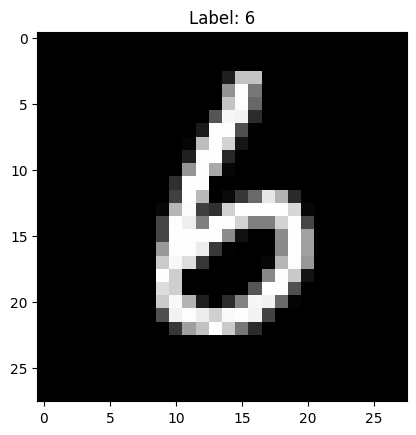

In [16]:
# plot the image corresponding to the random index
import matplotlib.pyplot as plt

plt.imshow(x_train[num].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_train[num]}')
plt.show()

In [17]:
# Test the test data with a random index
num = random.randint(0, x_test.shape[0] - 1)
print(f'Random index: {num}')   
print(f'y_test[{num}]: {y_test[num]}')  # should be a number between 0 and 9

Random index: 6127
y_test[6127]: 0


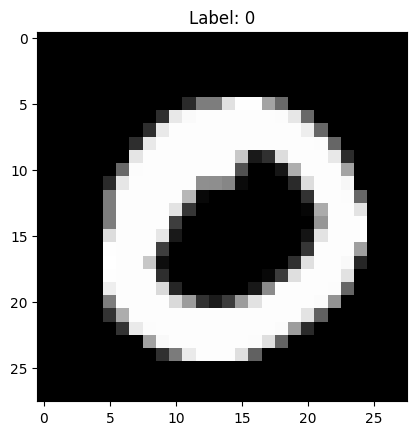

In [18]:
# plot the image corresponding to the random index
plt.imshow(x_test[num].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_test[num]}')
plt.show()

## Some additional functions to make MnistClass later

In [32]:
def one_hot_encode(labels, num_classes=10):
    """Convert an array of labels to one-hot encoded format."""
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot

In [20]:
labels = [1, 3, 5, 7, 9]
one_hot_labels = one_hot_encode(np.array(labels))
print(one_hot_labels)

[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


### Convert the original labels to one hot encoded labels

In [33]:
# convert y_train and y_test to one-hot encoded format
y_train_one_hot = one_hot_encode(y_train)
y_test_one_hot = one_hot_encode(y_test)

In [23]:
num = random.randint(0, x_test.shape[0] - 1)
print(f'Random index: {num}')

Random index: 9425


In [24]:
# print the label and the one-hot encoded label for the random index
print(f'y_test[{num}]: {y_test[num]}')  # should be a number between 0 and 9
print(f'y_test_one_hot[{num}]: {y_test_one_hot[num]}')  # should be a one-hot encoded vector of length 10

y_test[9425]: 0
y_test_one_hot[9425]: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Input normalization

In [34]:
# normalize the pixel values to be between 0 and 1
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

Random index: 12429


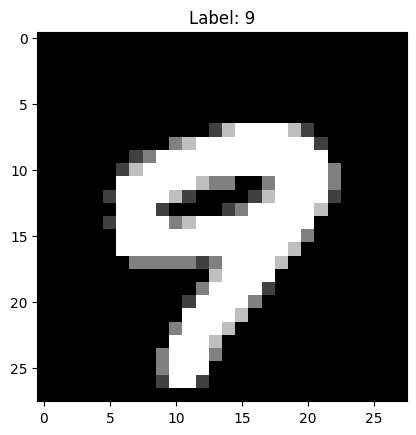

In [26]:
# test the normalization by printing the pixel values for a random index
num = random.randint(0, x_train.shape[0] - 1)
print(f'Random index: {num}')

# plot the image corresponding to the random index after normalization
plt.imshow(x_train_norm[num].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_train[num]}')
plt.show()

## MnistData class

In [ ]:
class MnistData:
    def __init__(self)
        self.mnist_data = {
            'x_train': None,
            'y_train': None,
            'x_test': None,
            'y_test': None
        }
        # add a lot more lines here...

    def _download(self):
        # add the download code here...
        pass

    def _load_images(self, filename):
        # add the code to load images here...
        pass

    def _load_labels(self, filename):
        # add the code to load labels here...
        pass

    def _one_hot_encode(self, labels, num_classes=10):
        # add the code to one-hot encode labels here...
        pass

    def _normalize(self, x):
        # add the code to normalize pixel values here...
        pass


    def _load_data(self):
        # add the code to load data here...
        # (x_train, y_train), (x_test, y_test) = # asign the loaded data to these variables
        pass 




## Use Pretrained Model

In [1]:
# import packages here
import os   
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#import mnist_data
from mnist_data import MnistData

data = MnistData()
# assume that image is normalized and label is one-hot encoded in the load_mnist_data function
(_, _), (x_test, y_test) = data.load_mnist_data()

In [5]:
PRETRAINED_MODEL_PATH = 'sample_weight.pkl'

In [6]:
def _load_network(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

In [7]:
net = _load_network(PRETRAINED_MODEL_PATH)

/tmp/ipykernel_10636/3414228591.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f)


In [9]:
print(net.keys())

dict_keys(['b2', 'W1', 'b1', 'W2', 'W3', 'b3'])


In [10]:
# let's check the shapes of the weights and biases in the loaded network
print("Shapes of weights and biases in the loaded network:")
for key in net.keys():
    print(f'{key}: {net[key].shape}')

Shapes of weights and biases in the loaded network:
b2: (100,)
W1: (784, 50)
b1: (50,)
W2: (50, 100)
W3: (100, 10)
b3: (10,)


In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [12]:
def softmax(x):
    c = np.max(x)
    e_x = np.exp(x - c)
    s_x = np.sum(e_x)
    return e_x / s_x

In [ ]:
def forward(network, x):
    w1, w2, w3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, w1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, w2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, w3) + b3
    y = softmax(a3)

    return y

In [ ]:
# test the forward function with a random index from the test set
num = random.randint(0, x_test_norm.shape[0] - 1)
print(f'Random index: {num}')
# print the predicted label and the true label for the random index
y_pred = forward(net, x_test_norm[num])
print(y_pred)
print(f'Predicted label: {np.argmax(y_pred)}')

Random index: 7639
[1.27693555e-04 1.08802868e-04 2.91060250e-05 9.11316102e-01
 1.94933815e-05 8.13819154e-02 6.76195020e-07 7.62166138e-04
 2.96089259e-03 3.29315142e-03]
Predicted label: 3


In [38]:
# print the true label for the random index
print(f'True label: {y_test[num]}')
print(f'True label (one-hot): {y_test_one_hot[num]}')

True label: 3
True label (one-hot): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


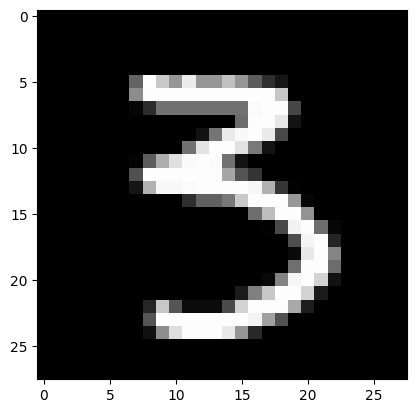

In [39]:
# plot the image corresponding to the random index
plt.imshow(x_test_norm[num].reshape(28, 28), cmap='gray')

### Mnist Class

In [40]:
## Utility functions for multilayer neural network implementation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    c = np.max(x)
    e_x = np.exp(x - c)
    s_x = np.sum(e_x)
    return e_x / s_x

In [ ]:
import pickle
import numpy as np
from mnist_data import MnistData
import utility

PRETRAINED_MODEL_PATH = 'sample_weight.pkl'

class Mnist: 
    def __init__(self):
        self.data = MnistData()
        (self.x_train, self.y_train), (self.x_test, self.y_test) = self.data.load_data()

        self.net = self._load_network()

    def _load_network(self):
        with open(PRETRAINED_MODEL_PATH, 'rb') as f:
            return pickle.load(f) 
        
    def forward(self, x):
        w1, w2, w3 = self.net['W1'], self.net['W2'], self.net['W3']
        b1, b2, b3 = self.net['b1'], self.net['b2'], self.net['b3']

        a1 = np.dot(x, w1) + b1
        z1 = utility.sigmoid(a1)
        a2 = np.dot(z1, w2) + b2
        z2 = utility.sigmoid(a2)
        a3 = np.dot(z2, w3) + b3
        y = utility.softmax(a3)

        return y
    

## Test Mnist and MnistData with your own handwritten numbers

In [43]:
from mnist import Mnist

In [44]:
# test Mnist class and the forward function with a random index from the test set
mnist = Mnist()
num = random.randint(0, mnist.x_test.shape[0] - 1)
print(f'Random index: {num}')
y_pred = mnist.forward(mnist.x_test[num])
print(y_pred)
print(f'Predicted label: {np.argmax(y_pred)}')


TypeError: cannot unpack non-iterable NoneType object